# Calibration of probabilities for breast cancer dataset

This notebook studies the calibration of probabilistic classifiers using the Breast Cancer Wisconsin dataset.

## 1. Import Libraries

In [1]:
"""Utilities for probability calibration and visualization."""
import numpy as np
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss


project_root = Path.cwd().parent
sys.path.append(str(project_root))


from scripts.calibration import PlattScaling, IsotonicRegression
from scripts.visualization import (
    plot_reliability_diagram,
    compare_reliability_diagrams,
    compare_all_calibrations
)

## 2. Load the Dataset

In [2]:
cancer = load_breast_cancer(as_frame=True)

X = cancer["data"]
y = cancer["target"].rename("target")

df = pd.concat([X, y], axis=1)

target = 0: malignant 

target = 1: benign

## 3. Exploratory Data Analysis (EDA)

### General describe

In [3]:
print(f"Number of observations: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")

Number of observations: 569
Number of variables: 31


In [4]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [6]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


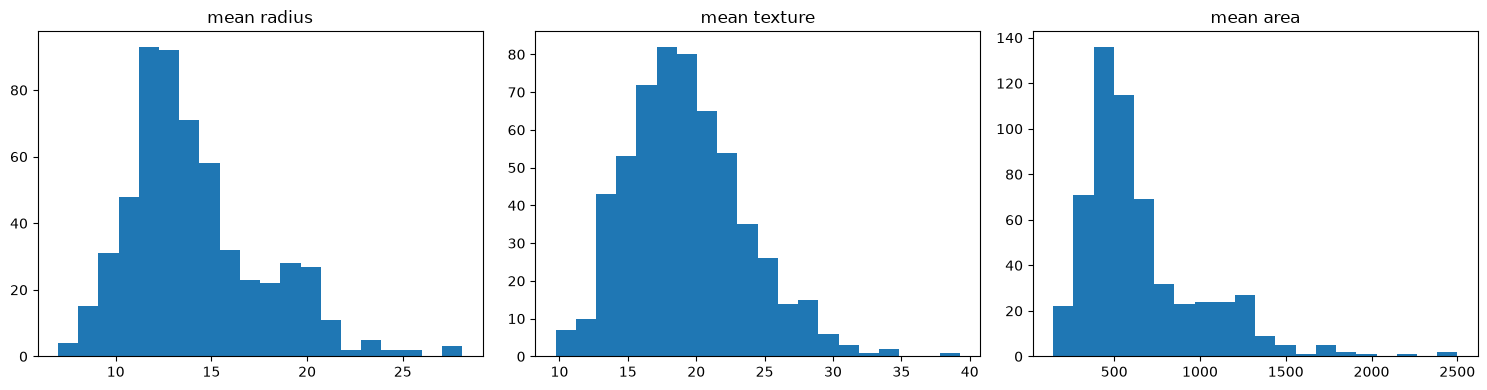

In [7]:
features = [
    "mean radius",
    "mean texture",
    "mean area"
]

plt.figure(figsize=(15,4))

for i, feature in enumerate(features):

    plt.subplot(1,3,i+1)

    plt.hist(df[feature], bins=20)

    plt.title(feature)

plt.tight_layout()
plt.show()

### Target distribution

In [8]:
target_summary = pd.DataFrame({
    "Count": df["target"].value_counts().sort_index(),
    "Percentage": (
        df["target"].value_counts(normalize=True).sort_index() * 100
    ).round(2)
})

target_summary.index = ["Malignant", "Benign"]

display(target_summary)

,Count,Percentage
Malignant,212,37.26
Benign,357,62.74


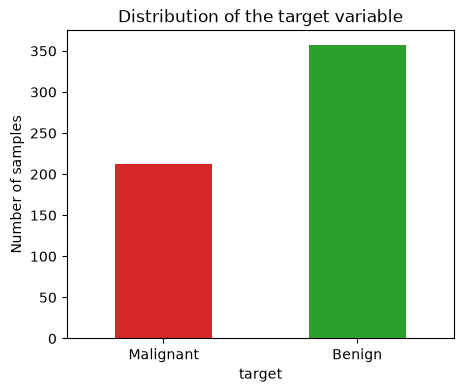

In [9]:
plt.figure(figsize=(5,4))

df["target"].value_counts().sort_index().plot(
    kind="bar",
    color=["#d62728", "#2ca02c"]
)

plt.xticks([0,1], ["Malignant", "Benign"], rotation=0)
plt.ylabel("Number of samples")
plt.title("Distribution of the target variable")

plt.show()

### Missing values

In [10]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [11]:
print(f"Total missing values: {df.isnull().sum().sum()}")

Total missing values: 0


### Correlation matrix

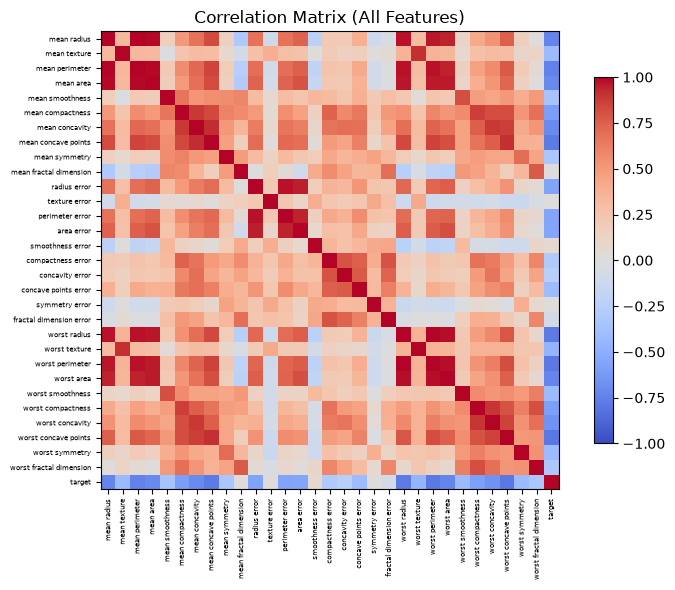

In [12]:
corr = df.corr()

plt.figure(figsize=(8, 6))

plt.imshow(corr,
           cmap="coolwarm",
           vmin=-1,
           vmax=1,
           interpolation="nearest")

plt.colorbar(shrink=0.8)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90,
    fontsize=5
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns,
    fontsize=5
)

plt.title("Correlation Matrix (All Features)", fontsize=12)

plt.tight_layout()
plt.show()

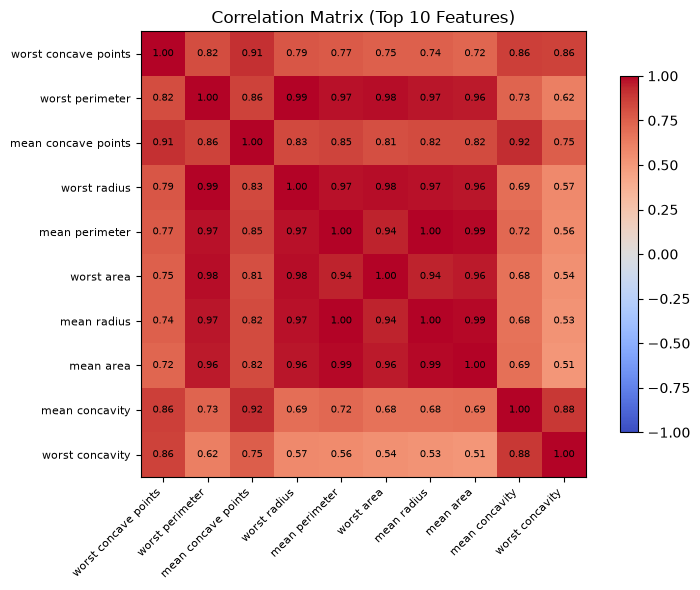

In [13]:
# Select the 10 features most correlated with the target
top_features = (
    df.corr()["target"]
    .abs()
    .sort_values(ascending=False)
    .index[1:11]       # exclude the target itself
)

corr_top = df[top_features].corr()

plt.figure(figsize=(8,6))

plt.imshow(
    corr_top,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    interpolation="nearest"
)

plt.colorbar(shrink=0.8)

plt.xticks(
    range(len(top_features)),
    top_features,
    rotation=45,
    ha="right",
    fontsize=8
)

plt.yticks(
    range(len(top_features)),
    top_features,
    fontsize=8
)

# Add correlation values
for i in range(len(corr_top)):
    for j in range(len(corr_top)):
        plt.text(
            j,
            i,
            f"{corr_top.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color="black"
        )

plt.title("Correlation Matrix (Top 10 Features)", fontsize=12)

plt.tight_layout()
plt.show()

The Breast Cancer dataset contains **569 observations** and **30 numerical features**, together with a binary target variable indicating whether a tumor is malignant or benign.

The dataset is clean, with **no missing values**, so no data cleaning is required before training the models.

The target classes are relatively balanced, with approximately **63% benign** and **37% malignant** samples, making the dataset suitable for binary classification.

The distributions of the selected features show different ranges and slight skewness, suggesting that feature scaling will be beneficial for models such as Logistic Regression.

Finally, the correlation analysis reveals that several features are highly correlated with each other, particularly those describing tumor size and shape. Many of these features also show a strong relationship with the target variable, indicating that they are likely to be informative for classification.

## 4. Data Preprocessing

### Feature Matrix and Target Vector

In [14]:
# Separate features and target

X = df.drop(columns="target")
y = df["target"]

In [15]:
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (569, 30)
Target vector shape: (569,)


### Train, Calibration and Test Split

In [16]:
x_train, x_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.50,
    random_state=42,
    stratify=y
)

In [17]:
x_cal, x_test, y_cal, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.40,
    random_state=42,
    stratify=y_temp
)

50 train, 20 test, 30 calibration

stratify=y beacause we have the same proportion of target in each groups

In [18]:
print("Training set:", x_train.shape)
print("Calibration set:", x_cal.shape)
print("Test set:", x_test.shape)

Training set: (284, 30)
Calibration set: (171, 30)
Test set: (114, 30)


#### Class Distribution after the Split

In [19]:
print("Training")
print(y_train.value_counts(normalize=True))

print("\nCalibration")
print(y_cal.value_counts(normalize=True))

print("\nTest")
print(y_test.value_counts(normalize=True))

Training
target
1    0.626761
0    0.373239
Name: proportion, dtype: float64

Calibration
target
1    0.625731
0    0.374269
Name: proportion, dtype: float64

Test
target
1    0.631579
0    0.368421
Name: proportion, dtype: float64


## 5. Logistic regression

#### Standardization

In [20]:
scaler = StandardScaler()

# Only on the training set
X_train_scaled = scaler.fit_transform(x_train)

# And apply to the others
X_cal_scaled = scaler.transform(x_cal)
X_test_scaled = scaler.transform(x_test)

### 5.1 Train Logistic Regression

In [21]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

#### Predicted Probabilities

In [22]:
y_prob_test_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
# probability that tumor is benign on test set

In [23]:
y_prob_cal_lr = log_reg.predict_proba(X_cal_scaled)[:, 1]
# probability that tumor is benign on calibration set

#### Predicted Classes

In [24]:
y_pred_test_lr = log_reg.predict(X_test_scaled)

### 5.2 Evaluation before Calibration

In [25]:
accuracy_lr = accuracy_score(y_test, y_pred_test_lr)
logloss_lr = log_loss(y_test, y_prob_test_lr)
brier_lr = brier_score_loss(y_test, y_prob_test_lr)

print(f"Accuracy:    {accuracy_lr:.4f}")
print(f"Log-loss:    {logloss_lr:.4f}")
print(f"Brier score: {brier_lr:.4f}")

Accuracy:    0.9649
Log-loss:    0.1642
Brier score: 0.0319


Accuracy: higher values indicate better classification performance.

Log-loss: lower values indicate better probabilistic predictions.

Brier score: lower values indicate better calibrated probability estimates.

#### Reliability diagram before calibration

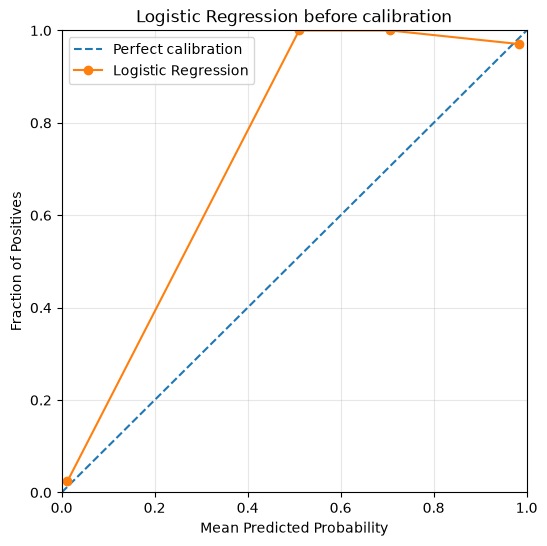

In [26]:
plot_reliability_diagram(
    y_test,
    y_prob_test_lr,
    model_label="Logistic Regression",
    title="Logistic Regression before calibration",
    n_bins=5
)

Predicted probabilities deviate from the perfect calibration line. This suggests that the Logistic Regression model is not perfectly calibrated.

### 5.3 Calibration with Platt Scaling

Platt Scaling is used to correct the probabilities produced by a model without retraining the model itself. Platt uses a separate set of data (the calibration set) to understand what actually happens in practice.

Transform the score into a probability using a sigmoid: 
sigmoid(A * score + B) = 1 / (1 + exp(-(A * score + B)))

Platt Scaling does not aim to make the model better at classification; instead, it aims to make the model's confidence in its predictions more reliable.

Platt Scaling is applied using the independent calibration set.  
The method learns a sigmoid transformation from the model scores to calibrated probabilities, without retraining the original classifier.

In [27]:
platt_lr = PlattScaling()

In [28]:
scores_cal_lr = log_reg.decision_function(X_cal_scaled)
scores_test_lr = log_reg.decision_function(X_test_scaled)

In [29]:
platt_lr = PlattScaling(
    learning_rate=0.01,
    max_iter=10000,
    tolerance=1e-7
)

In [30]:
platt_lr.fit(scores_cal_lr, y_cal)

#### Predicted Probabilities

In [31]:
y_prob_test_lr_platt = platt_lr.predict_proba(scores_test_lr)

#### Predicted Classes

In [32]:
y_pred_test_lr_platt = (y_prob_test_lr_platt >= 0.5).astype(int)

### 5.4 Evaluation after Platt Scaling

In [33]:
accuracy_lr_platt = accuracy_score(y_test, y_pred_test_lr_platt)
logloss_lr_platt = log_loss(y_test, y_prob_test_lr_platt)
brier_lr_platt = brier_score_loss(y_test, y_prob_test_lr_platt)

print(f"Accuracy:    {accuracy_lr_platt:.4f}")
print(f"Log-loss:    {logloss_lr_platt:.4f}")
print(f"Brier score: {brier_lr_platt:.4f}")

Accuracy:    0.9649
Log-loss:    0.1434
Brier score: 0.0308


#### Reliability diagram after calibration

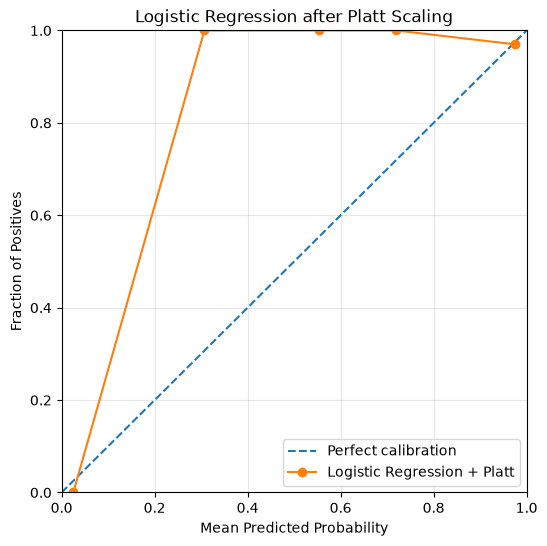

In [34]:
plot_reliability_diagram(
    y_test,
    y_prob_test_lr_platt,
    model_label="Logistic Regression + Platt",
    title="Logistic Regression after Platt Scaling",
    n_bins=5
)

### 5.5 Evaluation before and after Platt Scaling

In [35]:
comparison_platt_lr = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Log-loss",
        "Brier score"
    ],
    "Before calibration": [
        accuracy_lr,
        logloss_lr,
        brier_lr
    ],
    "After Platt": [
        accuracy_lr_platt,
        logloss_lr_platt,
        brier_lr_platt
    ]
})

display(comparison_platt_lr)

,Metric,Before calibration,After Platt
0,Accuracy,0.964912,0.964912
1,Log-loss,0.164179,0.143411
2,Brier score,0.031906,0.030758


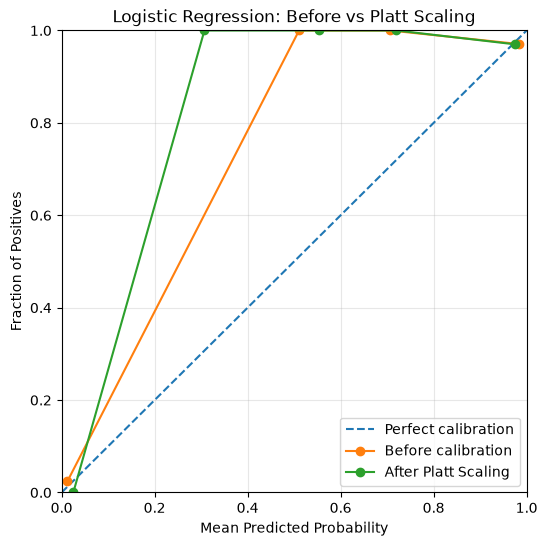

In [36]:
compare_reliability_diagrams(
    y_true=y_test,
    y_prob_before=y_prob_test_lr,
    y_prob_after=y_prob_test_lr_platt,
    label_before="Before calibration",
    label_after="After Platt Scaling",
    title="Logistic Regression: Before vs Platt Scaling",
    n_bins=5
)

Platt Scaling improves the calibration of Logistic Regression while preserving the same classification accuracy. Both Log-loss and Brier score decrease after calibration, indicating that the predicted probabilities become more reliable without affecting the model's classification performance.

### 5.6 Calibration with Isotonic Regression

Isotonic Regression is a non-parametric calibration method that learns a monotonic mapping between model scores and observed outcomes. 
It only requires that higher model scores should correspond to equal or higher calibrated probabilities.

The method fits a non-decreasing stepwise function on an independent calibration set, typically using the Pair-Adjacent Violators (PAV) algorithm. 
Isotonic Regression is more flexible than Platt Scaling, but it can overfit when the calibration set is small.

Idea: more score --> no less calibrated probability --> it does not impose a shape but only that it is increasing

In [37]:
isotonic_lr = IsotonicRegression()

In [38]:
isotonic_lr.fit(scores_cal_lr, y_cal)

#### Predicted Probabilities

In [39]:
y_prob_test_lr_isotonic = isotonic_lr.predict_proba(scores_test_lr)

#### Predicted Classes

In [40]:
y_pred_test_lr_isotonic = (y_prob_test_lr_isotonic >= 0.5).astype(int)

### 5.7 Evaluation after Isotonic Regression

In [41]:
accuracy_lr_isotonic = accuracy_score(y_test,y_pred_test_lr_isotonic)
logloss_lr_isotonic = log_loss(y_test,y_prob_test_lr_isotonic)
brier_lr_isotonic = brier_score_loss(y_test,y_prob_test_lr_isotonic)

print(f"Accuracy:    {accuracy_lr_isotonic:.4f}")
print(f"Log-loss:    {logloss_lr_isotonic:.4f}")
print(f"Brier score: {brier_lr_isotonic:.4f}")

Accuracy:    0.9737
Log-loss:    0.9555
Brier score: 0.0271


#### Reliability diagram after calibration

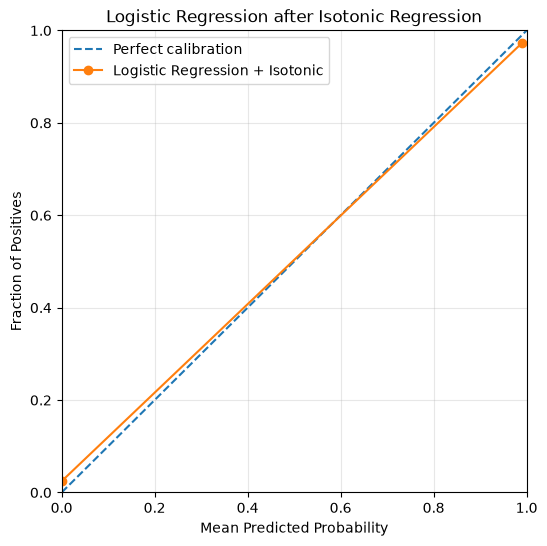

In [42]:
plot_reliability_diagram(
    y_test,
    y_prob_test_lr_isotonic,
    model_label="Logistic Regression + Isotonic",
    title="Logistic Regression after Isotonic Regression",
    n_bins=5
)

### 5.8 Evaluation before and after Isotonic Regression

In [43]:
comparison_lr = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Log-loss",
        "Brier score"
    ],

    "Before calibration": [
        accuracy_lr,
        logloss_lr,
        brier_lr
    ],

    "Isotonic Regression": [
        accuracy_lr_isotonic,
        logloss_lr_isotonic,
        brier_lr_isotonic
    ]
})

display(comparison_lr)

,Metric,Before calibration,Isotonic Regression
0,Accuracy,0.964912,0.973684
1,Log-loss,0.164179,0.955545
2,Brier score,0.031906,0.027138


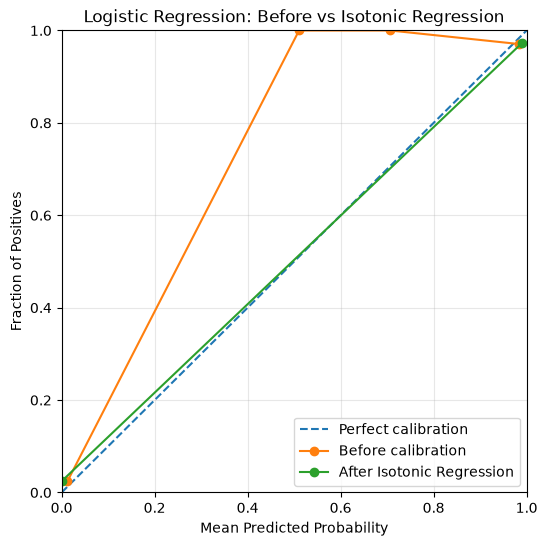

In [44]:
compare_reliability_diagrams(
    y_true=y_test,
    y_prob_before=y_prob_test_lr,
    y_prob_after=y_prob_test_lr_isotonic,
    label_before="Before calibration",
    label_after="After Isotonic Regression",
    title="Logistic Regression: Before vs Isotonic Regression",
    n_bins=5
)

Isotonic Regression produces mixed results. Brier score improve after calibration, but Log-loss increases substantially. This is mainly due to the extreme probabilities produced by Isotonic Regression (mostly 0 and 1), which are heavily penalized by Log-loss when the model makes an incorrect prediction.

In [45]:
print(np.unique(y_prob_test_lr_isotonic))

[0.    0.875 1.   ]


### 5.9 Evaluation before and after calibrations

In [46]:
comparison_lr = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Log-loss",
        "Brier score"
    ],

    "Before calibration": [
        accuracy_lr,
        logloss_lr,
        brier_lr
    ],

    "Platt Scaling": [
        accuracy_lr_platt,
        logloss_lr_platt,
        brier_lr_platt
    ],

    "Isotonic Regression": [
        accuracy_lr_isotonic,
        logloss_lr_isotonic,
        brier_lr_isotonic
    ]
})

display(comparison_lr)

,Metric,Before calibration,Platt Scaling,Isotonic Regression
0,Accuracy,0.964912,0.964912,0.973684
1,Log-loss,0.164179,0.143411,0.955545
2,Brier score,0.031906,0.030758,0.027138


Platt Scaling improves the probabilistic predictions of Logistic Regression while preserving the same classification accuracy. Both Log-loss and Brier score decrease after calibration, indicating better probability estimates. Isotonic Regression produces mixed results: it improves Brier score, but substantially worsens Log-loss. This can be explained by the very extreme probabilities produced by Isotonic Regression (mainly 0 and 1), which are heavily penalized by Log-loss when they are incorrect.

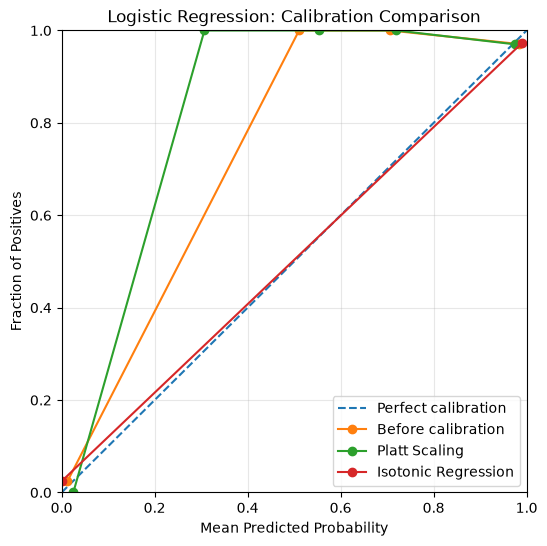

In [47]:
compare_all_calibrations(
    y_true=y_test,
    y_prob_before=y_prob_test_lr,
    y_prob_platt=y_prob_test_lr_platt,
    y_prob_isotonic=y_prob_test_lr_isotonic,
    title="Logistic Regression: Calibration Comparison",
    n_bins=5
)

In [48]:
print("Number of blocks:", len(isotonic_lr.values))
print("Unique calibrated probabilities:")
print(np.unique(y_prob_test_lr_isotonic))

Number of blocks: 162
Unique calibrated probabilities:
[0.    0.875 1.   ]


## 6. Random Forest

### 6.1 Train Random Forest

In [49]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

#### Predicted Probabilities

In [50]:
y_prob_test_rf = rf.predict_proba(x_test)[:, 1]

In [51]:
y_prob_cal_rf = rf.predict_proba(x_cal)[:, 1]

#### Predicted Classes

In [52]:
y_pred_test_rf = rf.predict(x_test)

### 6.2 Evaluation before calibration

In [53]:
accuracy_rf = accuracy_score(y_test, y_pred_test_rf)
logloss_rf = log_loss(y_test, y_prob_test_rf)
brier_rf = brier_score_loss(y_test, y_prob_test_rf)

print(f"Accuracy:    {accuracy_rf:.4f}")
print(f"Log-loss:    {logloss_rf:.4f}")
print(f"Brier score: {brier_rf:.4f}")

Accuracy:    0.9474
Log-loss:    0.4345
Brier score: 0.0428


Accuracy: higher values indicate better classification performance.

Log-loss: lower values indicate better probabilistic predictions.

Brier score: lower values indicate better calibrated probability estimates.

#### Reliability diagram before calibration

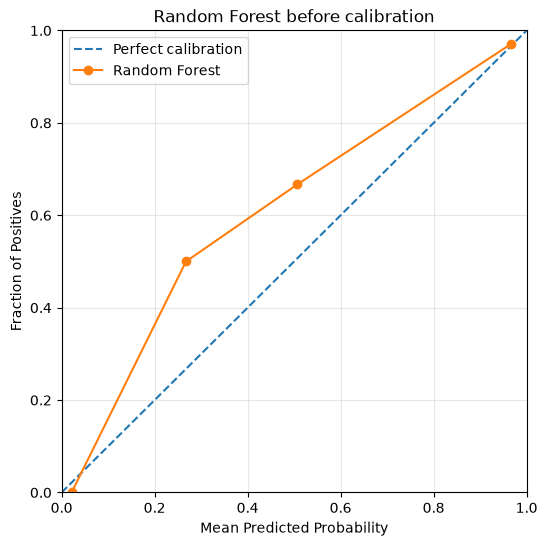

In [54]:
plot_reliability_diagram(
    y_test,
    y_prob_test_rf,
    model_label="Random Forest",
    title="Random Forest before calibration",
    n_bins=5
)

The Random Forest shows some miscalibration, particularly for intermediate predicted probabilities, where the observed fraction of positives is higher than the predicted probability. This suggests that the model tends to underestimate the probability of the positive class in these regions, leaving room for calibration methods to improve its probability estimates.

### 6.3 Calibration with Platt Scaling

Platt Scaling is used to correct the probabilities produced by a model without retraining the model itself. Platt uses a separate set of data (the calibration set) to understand what actually happens in practice.

Transform the score into a probability using a sigmoid: 
sigmoid(A * score + B) = 1 / (1 + exp(-(A * score + B)))

Platt Scaling does not aim to make the model better at classification; instead, it aims to make the model's confidence in its predictions more reliable.

Platt Scaling is applied using the independent calibration set.  
The method learns a sigmoid transformation from the model scores to calibrated probabilities, without retraining the original classifier.

In [55]:
platt_rf = PlattScaling(
    learning_rate=0.01,
    max_iter=10000,
    tolerance=1e-7
)

In [56]:
platt_rf.fit(y_prob_cal_rf, y_cal)

In [57]:
print(f"A: {platt_rf.a:.6f}")
print(f"B: {platt_rf.b:.6f}")

A: 5.165776
B: -2.294899


#### Predicted Probabilities

In [58]:
y_prob_test_rf_platt = platt_rf.predict_proba(y_prob_test_rf)

#### Predicted Classes

In [59]:
y_pred_test_rf_platt = (y_prob_test_rf_platt >= 0.5).astype(int)

### 6.4 Evaluation after Platt Scaling

In [60]:
accuracy_rf_platt = accuracy_score(y_test, y_pred_test_rf_platt)
logloss_rf_platt = log_loss(y_test, y_prob_test_rf_platt)
brier_rf_platt = brier_score_loss(y_test, y_prob_test_rf_platt)

print(f"Accuracy:    {accuracy_rf_platt:.4f}")
print(f"Log-loss:    {logloss_rf_platt:.4f}")
print(f"Brier score: {brier_rf_platt:.4f}")

Accuracy:    0.9474
Log-loss:    0.1835
Brier score: 0.0435


#### Reliability diagram after calibration

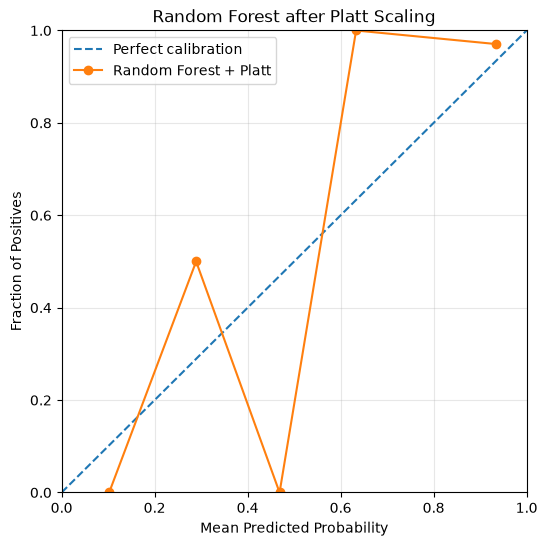

In [61]:
plot_reliability_diagram(
    y_test,
    y_prob_test_rf_platt,
    model_label="Random Forest + Platt",
    title="Random Forest after Platt Scaling",
    n_bins=5
)

### 6.5 Evaluation before and after Platt Scaling

In [62]:
comparison_platt_rf = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Log-loss",
        "Brier score"
    ],
    "Before calibration": [
        accuracy_rf,
        logloss_rf,
        brier_rf
    ],
    "After Platt": [
        accuracy_rf_platt,
        logloss_rf_platt,
        brier_rf_platt
    ]
})

display(comparison_platt_rf)

,Metric,Before calibration,After Platt
0,Accuracy,0.947368,0.947368
1,Log-loss,0.434469,0.183531
2,Brier score,0.042800,0.043540


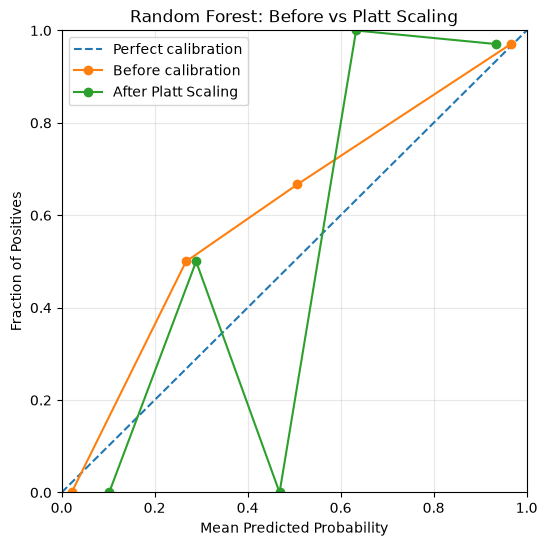

In [63]:
compare_reliability_diagrams(
    y_true=y_test,
    y_prob_before=y_prob_test_rf,
    y_prob_after=y_prob_test_rf_platt,
    label_before="Before calibration",
    label_after="After Platt Scaling",
    title="Random Forest: Before vs Platt Scaling",
    n_bins=5
)

Platt Scaling produces mixed results for the Random Forest. The classification accuracy remains unchanged, while Log-loss improves substantially, indicating better probabilistic predictions. However, the Brier score slightly increases, suggesting that the improvement in calibration is not consistent across all probability estimates.

### 6.6 Calibration with Isotonic Regression

Isotonic Regression is a non-parametric calibration method that learns a monotonic mapping between model scores and observed outcomes. 
It only requires that higher model scores should correspond to equal or higher calibrated probabilities.

The method fits a non-decreasing stepwise function on an independent calibration set, typically using the Pair-Adjacent Violators (PAV) algorithm. 
Isotonic Regression is more flexible than Platt Scaling, but it can overfit when the calibration set is small.

Idea: more score --> no less calibrated probability --> it does not impose a shape but only that it is increasing

In [64]:
isotonic_rf = IsotonicRegression()

In [65]:
isotonic_rf.fit(
    y_prob_cal_rf,
    y_cal
)

#### Predicted Probabilities

In [66]:
y_prob_test_rf_isotonic = isotonic_rf.predict_proba(y_prob_test_rf)

#### Predicted Classes

In [67]:
y_pred_test_rf_isotonic = (y_prob_test_rf_isotonic >= 0.5).astype(int)

### 6.7 Evaluation after Isotonic Regression

In [68]:
accuracy_rf_isotonic = accuracy_score(y_test, y_pred_test_rf_isotonic)
logloss_rf_isotonic = log_loss(y_test, y_prob_test_rf_isotonic)
brier_rf_isotonic = brier_score_loss(y_test, y_prob_test_rf_isotonic)

print(f"Accuracy:    {accuracy_rf_isotonic:.4f}")
print(f"Log-loss:    {logloss_rf_isotonic:.4f}")
print(f"Brier score: {brier_rf_isotonic:.4f}")

Accuracy:    0.9386
Log-loss:    1.9140
Brier score: 0.0586


#### Reliability diagram after calibration

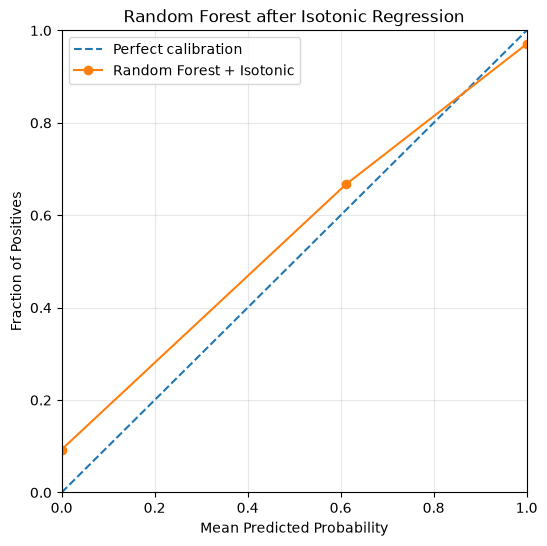

In [69]:
plot_reliability_diagram(
    y_test,
    y_prob_test_rf_isotonic,
    model_label="Random Forest + Isotonic",
    title="Random Forest after Isotonic Regression",
    n_bins=5
)

### 6.8 Evaluation before and after Isotonic Regression

In [70]:
comparison_isotonic_rf = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Log-loss",
        "Brier score"
    ],
    "Before calibration": [
        accuracy_rf,
        logloss_rf,
        brier_rf
    ],
    "Isotonic Regression": [
        accuracy_rf_isotonic,
        logloss_rf_isotonic,
        brier_rf_isotonic
    ]
})

display(comparison_isotonic_rf)

,Metric,Before calibration,Isotonic Regression
0,Accuracy,0.947368,0.938596
1,Log-loss,0.434469,1.913959
2,Brier score,0.042800,0.058561


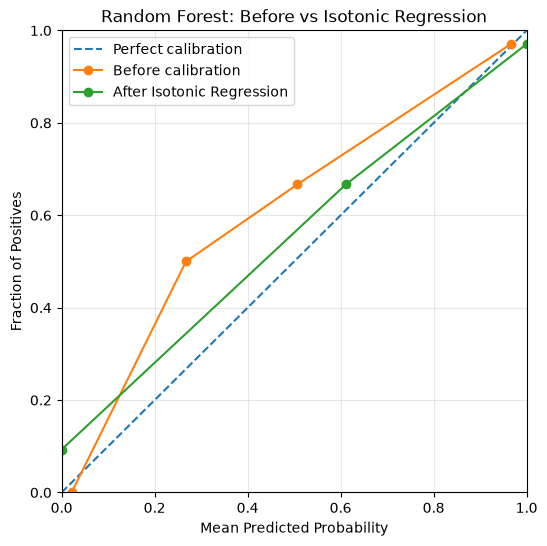

In [71]:
compare_reliability_diagrams(
    y_true=y_test,
    y_prob_before=y_prob_test_rf,
    y_prob_after=y_prob_test_rf_isotonic,
    label_before="Before calibration",
    label_after="After Isotonic Regression",
    title="Random Forest: Before vs Isotonic Regression",
    n_bins=5
)

Isotonic Regression does not improve the calibration of the Random Forest in this experiment. Accuracy decreases, while both Log-loss and Brier score increase. Although the reliability curve appears closer to perfect calibration in some probability regions, the overall probabilistic performance deteriorates, suggesting that Isotonic Regression may be overfitting the relatively small calibration set.

In [72]:
print(np.unique(y_prob_test_rf_isotonic))

[0.         0.61111111 1.        ]


### 6.9 Evaluation before and after calibrations

In [73]:
comparison_rf = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Log-loss",
        "Brier score"
    ],
    "Before calibration": [
        accuracy_rf,
        logloss_rf,
        brier_rf
    ],
    "Platt Scaling": [
        accuracy_rf_platt,
        logloss_rf_platt,
        brier_rf_platt
    ],
    "Isotonic Regression": [
        accuracy_rf_isotonic,
        logloss_rf_isotonic,
        brier_rf_isotonic
    ]
})

display(comparison_rf)

,Metric,Before calibration,Platt Scaling,Isotonic Regression
0,Accuracy,0.947368,0.947368,0.938596
1,Log-loss,0.434469,0.183531,1.913959
2,Brier score,0.042800,0.043540,0.058561


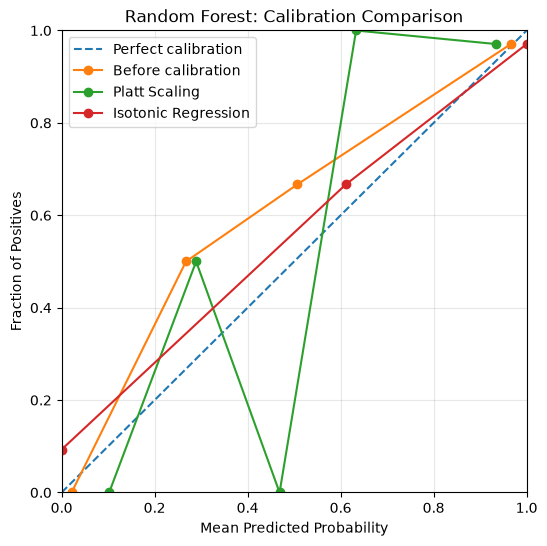

In [74]:
compare_all_calibrations(
    y_true=y_test,
    y_prob_before=y_prob_test_rf,
    y_prob_platt=y_prob_test_rf_platt,
    y_prob_isotonic=y_prob_test_rf_isotonic,
    title="Random Forest: Calibration Comparison",
    n_bins=5
)

Overall, Platt Scaling substantially improves Log-loss while maintaining the same accuracy, although the Brier score slightly worsens. In contrast, Isotonic Regression worsens all three metrics. Therefore, Platt Scaling provides the most beneficial calibration for the Random Forest in this experiment, despite the variability visible in the reliability diagram.

In [75]:
print("Number of blocks:", len(isotonic_rf.values))
print("Values:", isotonic_rf.values)
print("Thresholds:", isotonic_rf.thresholds)

print("\nUnique calibrated probabilities:")
print(np.unique(y_prob_test_rf_isotonic))

Number of blocks: 33
Values: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.61111111 1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.        ]
Thresholds: [0.   0.01 0.02 0.04 0.05 0.07 0.09 0.11 0.12 0.14 0.22 0.28 0.33 0.34
 0.36 0.73 0.74 0.79 0.81 0.83 0.85 0.89 0.9  0.91 0.92 0.93 0.94 0.95
 0.96 0.97 0.98 0.99 1.  ]

Unique calibrated probabilities:
[0.         0.61111111 1.        ]


## 7. Conclusion

In [76]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        " ",
        " ",
        "Random Forest",
        " ",
        " "
    ],

    "Calibration": [
        "No",
        "Platt Scaling",
        "Isotonic Regression",
        "No",
        "Platt Scaling",
        "Isotonic Regression"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_lr_platt,
        accuracy_lr_isotonic,
        accuracy_rf,
        accuracy_rf_platt,
        accuracy_rf_isotonic
    ],

    "Log-loss": [
        logloss_lr,
        logloss_lr_platt,
        logloss_lr_isotonic,
        logloss_rf,
        logloss_rf_platt,
        logloss_rf_isotonic
    ],

    "Brier score": [
        brier_lr,
        brier_lr_platt,
        brier_lr_isotonic,
        brier_rf,
        brier_rf_platt,
        brier_rf_isotonic
    ]
})

final_results.round(4)

,Model,Calibration,Accuracy,Log-loss,Brier score
0,Logistic Regression,No,0.9649,0.1642,0.0319
1,,Platt Scaling,0.9649,0.1434,0.0308
2,,Isotonic Regression,0.9737,0.9555,0.0271
3,Random Forest,No,0.9474,0.4345,0.0428
4,,Platt Scaling,0.9474,0.1835,0.0435
5,,Isotonic Regression,0.9386,1.9140,0.0586


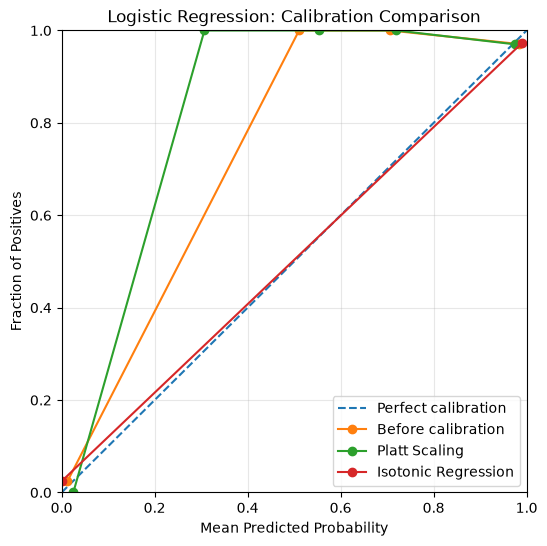

In [77]:
compare_all_calibrations(
    y_true=y_test,
    y_prob_before=y_prob_test_lr,
    y_prob_platt=y_prob_test_lr_platt,
    y_prob_isotonic=y_prob_test_lr_isotonic,
    title="Logistic Regression: Calibration Comparison",
    n_bins=5
)

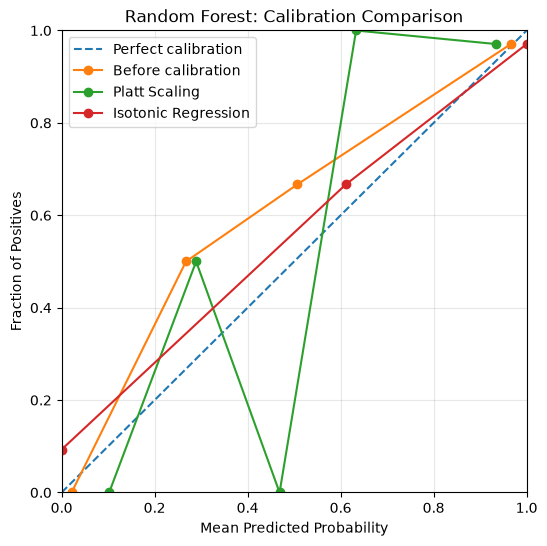

In [78]:
compare_all_calibrations(
    y_true=y_test,
    y_prob_before=y_prob_test_rf,
    y_prob_platt=y_prob_test_rf_platt,
    y_prob_isotonic=y_prob_test_rf_isotonic,
    title="Random Forest: Calibration Comparison",
    n_bins=5
)

Overall, the results show that the effect of probability calibration strongly depends on both the underlying classifier and the calibration method. Platt Scaling provides the most consistent improvements, reducing Log-loss for both Logistic Regression and Random Forest while preserving their classification accuracy. Isotonic Regression is less stable: it improves some metrics for Logistic Regression but performs poorly on Random Forest, particularly in terms of Log-loss. These results also highlight the importance of evaluating calibration using multiple metrics and reliability diagrams, since different measures may lead to different conclusions about the quality of the calibrated probabilities.